In [1]:
import numpy as numpy
import pandas as pd
import sklearn as skl
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

In [3]:
 #load dataset

data = load_breast_cancer()

x = pd.DataFrame(
    data.data,
    columns=data.feature_names #INDEPENDENT VAR W OTHER FEATURES
)

y = pd.Series(
    (data.target == 0).astype(int), #DEPENDENT VAR WITH TARGET VAR, HERE 0 MEANS MALIGNANT
    name='malignant'
)

print(y.value_counts())

print('feature matrix shape: ', x.shape)
print('target shape: ',y.shape)
print('class names: ',data.target_names)

malignant
0    357
1    212
Name: count, dtype: int64
feature matrix shape:  (569, 30)
target shape:  (569,)
class names:  ['malignant' 'benign']


In [4]:
class_counts = y.value_counts().sort_index() #value.counts() is an available method

class_distribution = pd.DataFrame({
"Class": data.target_names,
"Count" : class_counts,
"Probability": class_counts.values/len(y)
})

print(class_distribution)

               Class  Count  Probability
malignant                               
0          malignant    357     0.627417
1             benign    212     0.372583


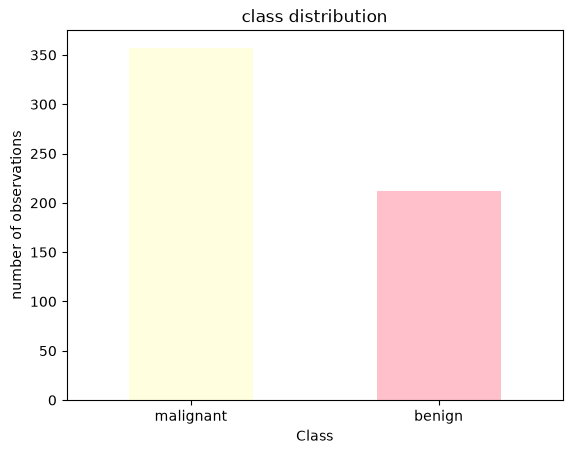

In [5]:
class_distribution.plot(
    x = 'Class',
    y = 'Count',
    kind='bar', #type of chart
    legend = False,
    color = ['lightyellow', 'pink'] #colours
)

plt.ylabel('number of observations')
plt.title('class distribution')
plt.xticks(rotation=0)
plt.show()

In [6]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y) #stratify so that test and train have similar distribution of both M and B data

In [7]:
print('Training size: ', len(y_train))
print('Testing size: ', len(y_test))

print('\n Training proportions: ')
print(y_train.value_counts(normalize=True).sort_index()) #check how many and % of M and B in both train and test

print('\n Testing proportions: ')
print(y_test.value_counts(normalize=True).sort_index())

Training size:  455
Testing size:  114

 Training proportions: 
malignant
0    0.626374
1    0.373626
Name: proportion, dtype: float64

 Testing proportions: 
malignant
0    0.631579
1    0.368421
Name: proportion, dtype: float64


In [8]:
model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)

model.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['mean radius','mean texture','mean perimeter',...,'worst concave points', 'worst symmetry','worst fractal dimension']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [9]:
probabilities = model.predict_proba(x_test) # predict prob in test and print first 5

print(probabilities[:5])

[[9.99635432e-01 3.64568116e-04]
 [1.07465986e-08 9.99999989e-01]
 [9.57432053e-01 4.25679471e-02]
 [4.23812678e-01 5.76187322e-01]
 [4.90844511e-01 5.09155489e-01]]


In [10]:
results = pd.DataFrame({
    "Actual_class": y_test.values,
    "P_malignant": probabilities[:,0],
    "P_benign" : probabilities[:,1]
})

print(results.head(10))

   Actual_class   P_malignant  P_benign
0             0  9.996354e-01  0.000365
1             1  1.074660e-08  1.000000
2             0  9.574321e-01  0.042568
3             1  4.238127e-01  0.576187
4             0  4.908445e-01  0.509155
5             0  9.993840e-01  0.000616
6             1  2.384659e-01  0.761534
7             0  9.989878e-01  0.001012
8             0  9.994313e-01  0.000569
9             0  9.892324e-01  0.010768


In [11]:
results ["Actual label"] = results["Actual_class"].map({
    0: 'Malignant',
    1: 'Benign'
})

print(
    results[
        ["Actual label", "P_malignant", "P_benign"]
    ].head(10)
)

  Actual label   P_malignant  P_benign
0    Malignant  9.996354e-01  0.000365
1       Benign  1.074660e-08  1.000000
2    Malignant  9.574321e-01  0.042568
3       Benign  4.238127e-01  0.576187
4    Malignant  4.908445e-01  0.509155
5    Malignant  9.993840e-01  0.000616
6       Benign  2.384659e-01  0.761534
7    Malignant  9.989878e-01  0.001012
8    Malignant  9.994313e-01  0.000569
9    Malignant  9.892324e-01  0.010768


In [12]:
threshold = 0.5

results["Predicted malignant"] = (
    results["P_malignant"] >= threshold
).astype(int)

results["Predicted_label"] = results[
    "Predicted malignant"
].map({
    1: "malignant",
    0: "benign"
})

print(
    results[
        [
        "Actual label",
        "P_malignant",
        "Predicted_label"
        ]
    ].head(10)
)

  Actual label   P_malignant Predicted_label
0    Malignant  9.996354e-01       malignant
1       Benign  1.074660e-08          benign
2    Malignant  9.574321e-01       malignant
3       Benign  4.238127e-01          benign
4    Malignant  4.908445e-01          benign
5    Malignant  9.993840e-01       malignant
6       Benign  2.384659e-01          benign
7    Malignant  9.989878e-01       malignant
8    Malignant  9.994313e-01       malignant
9    Malignant  9.892324e-01       malignant


In [13]:
for threshold in [0.30, 0.50, 0.70]:
    predictions = (
        results["P_malignant"] >= threshold
    ).astype(int)

    print(
        f"Threshold = {threshold}: "
        f"Predicted malignant cases = {predictions.sum()}"
    )

Threshold = 0.3: Predicted malignant cases = 76
Threshold = 0.5: Predicted malignant cases = 74
Threshold = 0.7: Predicted malignant cases = 72


In [14]:
actual_malignant = (y_test.values ==0).astype(int)

for threshold in [0.30, 0.50, 0.70]:
    predicted_malignant = (
        probabilities[:,0] >= threshold
    ).astype(int)

    cm = confusion_matrix(
        actual_malignant.tolist(),
        predicted_malignant.tolist()
    )
    print(f"\nConfusion Matrix for Threshold = {threshold}:")
    print(cm)


Confusion Matrix for Threshold = 0.3:
[[38  4]
 [ 0 72]]

Confusion Matrix for Threshold = 0.5:
[[39  3]
 [ 1 71]]

Confusion Matrix for Threshold = 0.7:
[[41  1]
 [ 1 71]]


# accuracy = tp+tn/all
(how many corrrectly detected M or B)
# precision = tp/tp+fp 
(among detected malignant how many were ACTUALLY malignant)
# recall = tp/tp+fn [sensitivity]
(among malignant, how many were detected malignant)
# specificity = tn/tn+fp
(among benign, how many detected benign)
# Fl score = 2(precision*recall/precision+recall)

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [16]:
metrics_data = []
thresholds = [0.1, 0.3, 0.5, 0.7, 0.9] #we need to check for all these thresholds

for threshold in thresholds:
    predicted_malignant = (
        probabilities[:, 0] >= threshold # 0 is M and 1 is B, so if p of 0 > threshold then its pred M
    ).astype(int)

    cm = confusion_matrix(
        actual_malignant.tolist(),
        predicted_malignant.tolist()
    )
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0,0,0,0) # convert into 1d array and handle cases where confusion matrix might not be 2x2

    accuracy = accuracy_score(actual_malignant, predicted_malignant)
    precision = precision_score(actual_malignant, predicted_malignant, zero_division=0)
    recall = recall_score(actual_malignant, predicted_malignant, zero_division=0)
    f1 = f1_score(actual_malignant, predicted_malignant, zero_division=0)

    metrics_data.append({
        'Threshold': threshold,
        'TN': tn,
        'FP': fp,
        'FN': fn,
        'TP': tp,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

metrics_df = pd.DataFrame(metrics_data)
display(metrics_df.round(3))

,Threshold,TN,FP,FN,TP,Accuracy,Precision,Recall,F1-Score
0,0.1,33,9,0,72,0.921,0.889,1.000,0.941
1,0.3,38,4,0,72,0.965,0.947,1.000,0.973
2,0.5,39,3,1,71,0.965,0.959,0.986,0.973
3,0.7,41,1,1,71,0.982,0.986,0.986,0.986
4,0.9,41,1,5,67,0.947,0.985,0.931,0.957
